### Data Mining and Wrangling
#### Regression Algorithms
##### 16th October 2025

Linear Regression, Decision Tree Regressor etc

**Dataset:** `fetch_california_housing()`

### Learning Outcomes:
By end of this session, you will be able to:
- Understand supervised learning for continuous targets
- Implement three regression models with scikit-learn
- Evaluate using MAE, MSE, RMSE, and R²
- Visualize predictions vs actuals and residuals

In [1]:
### importing the necessary packages and the dataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [2]:
### loading the dataset
data = fetch_california_housing()
X = data.data
y = data.target

In [3]:
X

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8))

In [21]:
## displaying the feature names as well 
feature_names = data.feature_names
f'Features {len(feature_names)}:, {feature_names}'

"Features 8:, ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']"

In [4]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="HouseValue")

In [5]:
f'X shape:{X.shape}, y shape:, {y.shape}'

'X shape:(20640, 8), y shape:, (20640,)'

In [6]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


#### Splitting the data into training and testing sets


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((16512, 8), (4128, 8))

### 1) Linear Regression

#### 1.1 Simple linear regression

In [8]:
X_simple = X[["MedInc"]]
y = data.target

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

In [10]:
#### model
linear_reg_simple = LinearRegression()
linear_reg_simple.fit(X_train, y_train)

LinearRegression()

In [11]:
### making predictions
y_pred = linear_reg_simple.predict(X_test)

In [13]:
### model evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f},\nMSE: {mse:.3f},\nR²: {r2:.3f}")


MAE: 0.630,
MSE: 0.709,
R²: 0.459


-  Visualization

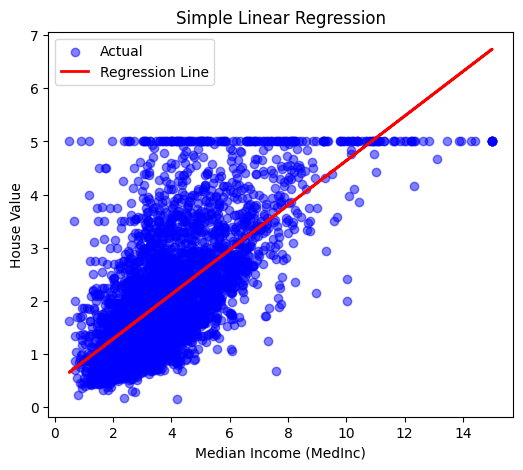

In [39]:
plt.figure(figsize=(6,5))
plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel("Median Income (MedInc)")
plt.ylabel("House Value")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()


In [19]:
X.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000


## 2) Multiple linear regression
Utilizing all the available features to predict the target variable.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### standardizing features to deal with scale differences
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
linear_reg_multi = LinearRegression()
linear_reg_multi.fit(X_train_scaled, y_train)

## making predictions
y_pred_multi = linear_reg_multi.predict(X_test_scaled)

In [16]:
### model evaluation
mae_m = mean_absolute_error(y_test, y_pred_multi)
mse_m = mean_squared_error(y_test, y_pred_multi)
r2_m = r2_score(y_test, y_pred_multi)

In [17]:
print(f"\nMAE: {mae_m:.3f},\nMSE: {mse_m:.3f},\nR²: {r2_m:.3f}")


MAE: 0.533,
MSE: 0.556,
R²: 0.576


### visualization

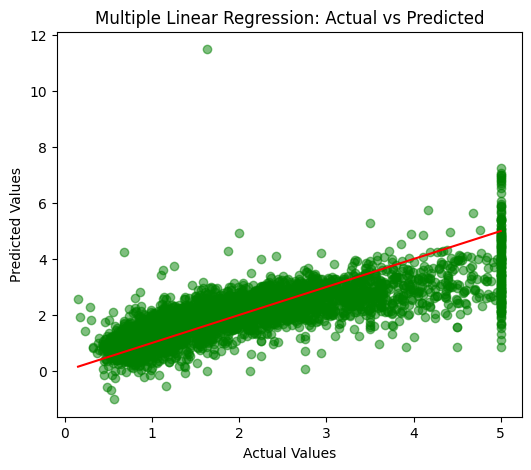

In [51]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_multi, color='green', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r-')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.show()


- Individual feature contribution to predictions

In [52]:
coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_reg_multi.coef_
}).sort_values("Coefficient", ascending=False)

coeffs

,Feature,Coefficient
0,MedInc,0.854383
3,AveBedrms,0.339259
1,HouseAge,0.122546
4,Population,-0.002308
5,AveOccup,-0.040829
2,AveRooms,-0.294410
7,Longitude,-0.869842
6,Latitude,-0.896929


In [58]:
tree = DecisionTreeRegressor(max_depth=6, random_state=42)
tree.fit(X_train, y_train)
y_pred_tr = tree.predict(X_test)
mae_tr = mean_absolute_error(y_test, y_pred_tr)
mse_tr = mean_squared_error(y_test, y_pred_tr)
rmse_tr = root_mean_squared_error(y_test, y_pred_tr)
r2_tr = r2_score(y_test, y_pred_tr)
print(f'MAE: {mae_tr:.4f} \nMSE: {mse_tr:.4f} \nRMSE: {rmse_tr:.4f} \nR2: {r2_tr:.2f}') 

MAE: 0.5008 
MSE: 0.4973 
RMSE: 0.7052 
R2: 0.62


## 3) Decision tree regressor
Recursive partitioning of feature space with piecewise constant predictions.

In [59]:
tree = DecisionTreeRegressor(max_depth=6, random_state=42)
tree.fit(X_train, y_train)
y_pred_tr = tree.predict(X_test)
mae_tr = mean_absolute_error(y_test, y_pred_tr)
mse_tr = mean_squared_error(y_test, y_pred_tr)
rmse_tr = root_mean_squared_error(y_test, y_pred_tr)
r2_tr = r2_score(y_test, y_pred_tr)
print(f'MAE: {mae_tr:.4f} \nMSE: {mse_tr:.4f} \nRMSE: {rmse_tr:.4f} \nR2: {r2_tr:.2f}') 

MAE: 0.5008 
MSE: 0.4973 
RMSE: 0.7052 
R2: 0.62


- feature importance 

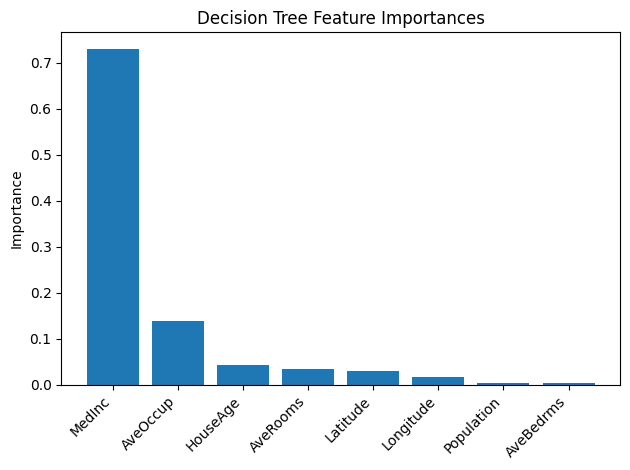

In [61]:
importances = tree.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure()
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=45, ha='right')
plt.ylabel('Importance')
plt.title('Decision Tree Feature Importances')
plt.tight_layout()
plt.show()